# LMECA2300: Advanced Numerical Methods
## Assignment 3

**Students:**
- Student 1: Victor Lepère (61502000)
- Student 2: Max Opdecam(77062000)

### Question 1: Pressure field on the segment

Given a segment made of two points, $\mathbf{r_1}'$ and $\mathbf{r_2}'$, and is denoted by $\Gamma'$, we recall that the complex amplitude of the pressure wave at $\mathbf r$ is given by
$$
p(\mathbf{r}) = \frac{\omega \rho_0}{4} \int_{\Gamma'} H_0^{(2)} (k \rho) v_n d\Gamma'
$$
Where
- $\omega$ is the angular frequency;
- $k$ is the wavenumber;
- $\rho$ is the distance between $\mathbf{r}$ and $\mathbf{r}'$;
- $v_n$ is the normal velocity, assumed constant in this context.

Here we assume that $\mathbf r$ lies on the segment $\Gamma'$. Hence we can split the segment into two smaller ones, from $\mathbf r_1'$ to $\mathbf r$ and from $\mathbf r$ to $\mathbf r_2'$, respectively denoted by $\Gamma_1'$ and $\Gamma_2'$. Therefore,
\begin{align*}
p(\mathbf{r}) &= \frac{\omega \rho_0}{4} \int_{\mathbf{r_1}'}^{\mathbf{r_2}'} H_0^{(2)} (k \rho(\mathbf{r}')) v_n d\mathbf{r}' \\
&= v_n \frac{\omega \rho_0}{4} \left [ \int_{\mathbf{r_1}'}^{\mathbf{r}} H_0^{(2)} (k \rho(\mathbf{r}')) d\mathbf{r}' + \int_{\mathbf{r}}^{\mathbf{r_2}'} H_0^{(2)} (k \rho(\mathbf{r}')) d\mathbf{r}' \right ] \\
&= v_n \frac{\omega \rho_0}{4} \left [ \int_{0}^{1} H_0^{(2)} (k ||\mathbf r - (\mathbf r_1' + s (\mathbf r - \mathbf r_1'))||_2 ) L_1 ds + \int_{0}^{1} H_0^{(2)} (k ||\mathbf r - (\mathbf r + s (\mathbf r_2' - \mathbf r))||_2 ) L_2 ds \right ] \\
\end{align*}

where $L_i = ||\mathbf r - \mathbf r_i'||_2$. We can now exploit the symmetry of the distance metric. Let $\bar s = \frac{\min(L_1, L_2)}{\max(L_1, L_2)}$. If $L_1 < L_2$, we have
\begin{align*}
p(\mathbf{r}) &= v_n \frac{\omega \rho_0}{4} \left [ (L_2 + L_2) \int_{0}^{\bar s} H_0^{(2)} (k \rho(s, \mathbf r_2') ) ds + L_2 \int_{\bar s}^1 H_0^{(2)} (k \rho(s, \mathbf r_2') ) ds \right ] \\ 
\end{align*}
We don't need to calculate the intregrale for all the segment we can use the fact that the segment is symetrique to only calcule one half and manually impose the symmetry later

We can now analytically extract the singularities as follows

\begin{align*}
\int_{a}^{b} H_0^{(2)} (k \rho(s, \mathbf r_2') ) ds = \int_{a}^{b} H_0^{(2)} (k \rho(s, \mathbf r_2') ) + j \frac{2}{\pi} \ln (k \rho(s, \mathbf r_2') )  ds - j \frac{2}{\pi} \int_{a}^{b} \ln (k \rho(s, \mathbf r_2') )  ds
\end{align*}

We can compute the first integral using the composite Trapezium rule with integration nodes $a + \frac{i}{m} (b-a)$ where $i = 0, 1, \dots, m$ and by considering $1 - j \frac{2}{\pi} (\gamma - \ln 2)$ when $k \rho(s, \mathbf r_2') \in \mathcal{O} \left ( \frac{\lambda}{1000} \right )$. The second integral is calculated analytically as follows:
\begin{align*}
\int_{a}^{b} \ln (k \rho(s, \mathbf r_2') )  ds &= (b-a) \ln(k) +  \int_{a}^{b} \ln (\rho(s, \mathbf r_2') )  ds \\
\end{align*}
and the last intergrale can be reduce to.
\begin{align*}
\int_{a}^{b} \ln (\rho(s, \mathbf r_2') )  ds &= \int_{a}^{b} \ln ||\mathbf r - (\mathbf r + s (\mathbf r_2' - \mathbf r))||_2  ds \\
&= (b - a) \ln ||\mathbf r_2' - \mathbf r||_2 + \int_a^b \ln s  \ ds \\
&= (b - a) \ln ||\mathbf r_2' - \mathbf r||_2 + \left [ s (\ln s - 1) \right ]_a^b \\
\end{align*}

Find below the implementation of the above development.

In [4]:

### Imports
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation
from scipy.special import hankel2
from math import ceil

### Physical constants
rho0 = 1.2 # air, 20°C, 1 atm
f = 10 # [hz]
w = 2*np.pi*f # air -> 343 = w/k
k = w/343
lambda_ = (2*np.pi)/k

### A segment
class Edge:
    def __init__(self,r1,r2):
        self.r1 = r1
        self.r2 = r2
    def norm(self):
        r = self.r1-self.r2
        return(np.sqrt(r[0]**2 + r[1]**2))
    def __integrate_hankel(self, a, b, m, case):
        """
        Aux. function that integrates Hankel function from a to b

        @param a: lower intergration bound
        @param b: upper integration bound
        @param case: symmetric/general case
        @param m: number of integration points
        """
        s = np.linspace(a, b, m)
        if case == 1:
            diff = s[:, np.newaxis] * (self.r2 - self.obs)
        else:
            diff = self.obs - (self.r1 + s[:, np.newaxis] * (self.r2 - self.r1))
        rho = np.linalg.norm(diff, axis=1)
        singularity_mask = k*rho <= lambda_/1000

        evals = np.zeros_like(rho, dtype=np.complex128)
        cst = 1 - 1j*(2/np.pi)*(np.euler_gamma - np.log(2))
        evals[singularity_mask] = cst
        subset_rho = rho[~singularity_mask]
        evals[~singularity_mask] = hankel2(0, k*subset_rho) + 1j*(2/np.pi)*np.log(k*subset_rho)

        h = (b - a) / m

        evals[0] *= 1/2
        evals[-1] *= 1/2
        first_term = h*np.sum(evals)
        if case == 1:
            if a == 0:
                last = 0
            else:
                last = a*(np.log(a)-1)
            second_term = -1j*(2/np.pi)*((b-a)*(np.log(k)+np.log(np.linalg.norm(self.r2-self.obs))) + (b*(np.log(b)-1) - last))
        else:
            pass

        return first_term + second_term
    
    def integral(self, Vn, obs,m):
        """
        Parameters
        ----------
        Vn : float
            constant normal velocity w.r.t interface
        obs : 2d array
            grid of observation points.

        Returns
        -------
        l'intégrale.

        """
        obs = np.atleast_2d(obs) # (N,2)

        s = np.linspace(0, 1, m) # (m,)
        diff = obs[:, np.newaxis, :] - (self.r1 + s[:, np.newaxis] * (self.r2-self.r1)) # (N,m,2)
        rho = np.linalg.norm(diff, axis=-1) # (N,m)

        H = hankel2(0, k * rho) # (N,m)
        if np.any(np.isnan(H)):
            raise ValueError("Hankel function evaluated at singular point, change geometry or grid.")
        H[:, 0] *= 1/2
        H[:, -1] *= 1/2
        integral = w * rho0 * Vn * self.norm() * np.sum(H, axis=1)/4 / m # (N,)
        return integral
        
        
    def integrate_sym(self, Vn, obs):
        """
        Integrates complex amplitude for an obsever point ON the segment, and thus takes advantage of symmetry.

        @param Vn: constant normal velocity
        @param obs: coord. of observer
        """
        self.obs = obs
        L1 = np.linalg.norm(obs - self.r1)
        L2 = np.linalg.norm(obs - self.r2)

        sbar = np.fmin(L1, L2) / np.fmax(L1, L2)

        m = 40
        if L1 == 0:
            return (Vn*w*rho0*L2/4)*self.__integrate_hankel(0, 1, m, 1)
        elif L1 < L2:
            return (Vn*w*rho0/4)*((L2+L2)*self.__integrate_hankel(0, sbar, m, 1) + (L2)*self.__integrate_hankel(sbar, 1, m, 1))
        else:
            return (Vn*w*rho0*L1/2)*self.__integrate_hankel(0, 1, m, 1)
        


After calculationg the phasor we manualy impose the symmetry and plot the result

WARNING : JUPITER says there an error in the title but it still run and put the title correctly

In [5]:
r1 = np.array([-lambda_/10, 0])
r2 = np.array([lambda_/10, 0])
# r1 = np.array([1, 0])
# r2 = np.array([1+lambda_/10, 0])
edge = Edge(r1, r2)

pressure_nodes = np.linspace(r1,(r1+r2)/2,100)

phasors = [edge.integrate_sym(1, obs) for obs in pressure_nodes]

#we impose the symmetry here
temp = np.flip(phasors)
phasors = np.hstack((phasors,temp[1:]))
phasors = np.array(phasors, dtype=np.complex128)
temp = np.flip(-pressure_nodes,0)
pressure_nodes = np.vstack((pressure_nodes,temp[1:]))
np.savetxt("phasors100.txt", phasors)

plt.rcParams["animation.html"] = "jshtml"
plt.ioff()

fig, ax = plt.subplots()
delta_t = (1/f)/10

def animate(t):
    plt.cla()
    pressures = np.real(phasors * np.exp(1j*t*w*delta_t))
    plt.plot(pressure_nodes[:, 0], pressures, linewidth=2,color = 'red')
    plt.plot([r1[0], r2[0]], [r1[1], r2[1]], 'k', linewidth=2)
    ax.set_title("Pressure field $\Delta$t = %f seg" %delta_t)
    plt.xlim(r1[0]-lambda_/100, r2[0]+lambda_/100)
    plt.ylim(-200, 200)
    plt.xlabel("$x$")
    plt.ylabel("pressure")
    fig.tight_layout()
    
matplotlib.animation.FuncAnimation(fig, animate, frames=100, interval=100)

We must now verify the continuity of our solution with the rest of the radiation we decied to take the advice of the theacher and create an arbritary perpendicular segment (in bleu) where we are going to calcule the radiation like in last homework over our souce segment (in red)

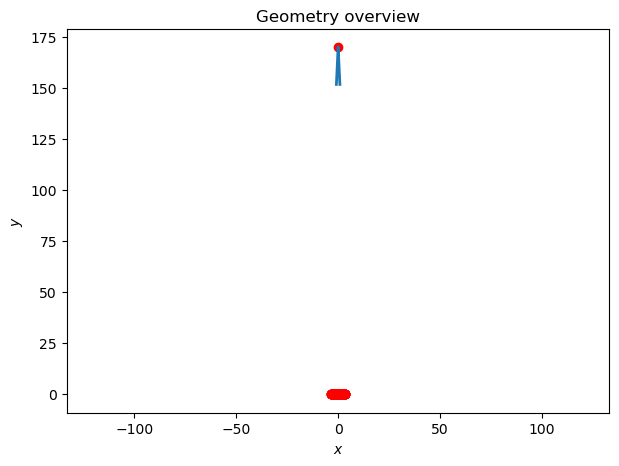

In [ ]:

gridsize = 101
y = np.linspace(-lambda_/40, lambda_/40,gridsize)
x = np.zeros_like(y)
x[:] = pressure_nodes[75,0]
coord_array = np.column_stack((x, y))
plt.scatter(coord_array[:, 0], coord_array[:, 1], c='gray', marker='.', s=1)
plt.scatter(pressure_nodes[:, 0], pressure_nodes[:,1],color = 'red')
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.axis('equal')
plt.title("Geometry overview")
plt.show()


To show the continuity in the middle we had to use 20000 point over our very small segment . The red point is the pressure we calculed on the segment using the smooth intregral while the bleu ligne is the pressure calculated using the technique in HW2.

In [15]:
m=20000
phasors_2 = [edge.integral(1, obs,m) for obs in coord_array]
phasors_2 = np.array(phasors_2, dtype=np.complex128)
plt.rcParams["animation.html"] = "jshtml"
plt.ioff()

fig, ax = plt.subplots()
delta_t = (1/f)/10

def animate2(t):
    plt.cla()
    pressures_2 = np.real(phasors_2 * np.exp(1j*t*w*delta_t))
    pressures =  np.real(phasors[75] * np.exp(1j*t*w*delta_t))
    plt.plot(coord_array[:, 1], pressures_2, linewidth=2)
    plt.scatter(0, pressures,color = 'red')
    ax.set_title("Pressure field $\Delta$t = %f seg" %delta_t)
    plt.xlim(y[0],y[-1])
    plt.ylim(-200, 200)
    plt.xlabel("$y$")
    plt.ylabel("pressure")
    fig.tight_layout()
    
matplotlib.animation.FuncAnimation(fig, animate2, frames=100, interval=100)

The point and the curve colide with one another we have continuity